# Series로 1차원 배열 다루기

In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np

## 1. Series란?

- Series는 Pandas의 1차원 데이터 구조이다.
- 엑셀에서의 한개 열(column)과 비슷

In [2]:
s = pd.Series([25, 34, 19])
s

0    25
1    34
2    19
dtype: int64

In [5]:
array1 = np.array([1, 2, 3, 4, 5])
s1 = pd.Series(array1, index = ['a', 'b', 'c', 'd', 'e'])
s1

a    1
b    2
c    3
d    4
e    5
dtype: int64

In [6]:
dict1 = {'number' : [1, 2, 3]}
s1 = pd.Series(dict1)
s1

number    [1, 2, 3]
dtype: object

In [10]:
dict2 = {
    'apple': '🍎',
    'orange' : '🍅',
    'lemon' : '🍋'
        }
s1 = pd.Series(dict2)
print(s1.index)

Index(['apple', 'orange', 'lemon'], dtype='object')


## 2. Series 기본 정보 확인

In [11]:
# 데이터 생성
s = pd.Series([1, 2, 3])
s

0    1
1    2
2    3
dtype: int64

In [16]:
# 사이즈 확인
print(len(s), s.size)        # .size는 pandas의 series만 사용

3 3


In [17]:
# 사이즈 형태 확인
s.shape

(3,)

In [18]:
# 사이즈의 데이터 타입 확인
s.dtype

dtype('int64')

In [22]:
# 사이즈의 인덱스 확인
print(f"인덱스 범위 : {s.index}")
print(f"인덱스 값 : {s.index.values}")

인덱스 범위 : RangeIndex(start=0, stop=3, step=1)
인덱스 값 : [0 1 2]


## 3. iloc & loc
- 인덱스 검색 방식
- integer location & location
- iloc : 인덱스가 0,1,2... 진행된다고 생각하고 뽑음
- loc : 실제 인덱스 (a,b,c 이런식으로 될 때 그 인덱스에 있는 값 가져옴)
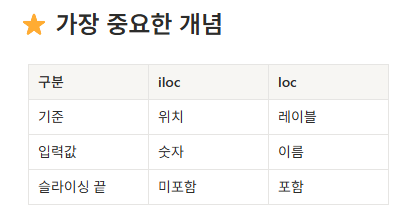

In [23]:
s1 = pd.Series([1, 2, 3])
s1

0    1
1    2
2    3
dtype: int64

In [33]:
print(s1.iloc[2])
print(s1.loc[2])
print(s1.iloc[1:2])         # 인덱스 1인 idx : 1, val : 2 가져옴
print(s1.loc[1:2])          # 인덱스 1, 2인   (1,2), (2,3) 가져옴

3
3
1    2
dtype: int64
1    2
2    3
dtype: int64


In [34]:
s2 = pd.Series([1, 2, 3, 4], index = ['a','b','c','d'])
s2

a    1
b    2
c    3
d    4
dtype: int64

In [36]:
print(s2.iloc[2])
# print(s2.loc[2])            loc은 실제 입력되어 있는 index를 기준으로 찾으므로 err

3


In [39]:
print(s2.loc['a'])
print(s2.loc['a':'b'])            # 마지막 인덱스 'b'도 결과에 포함!!

1
a    1
b    2
dtype: int64


## 4. 조건 슬라이싱

In [43]:
narray = np.arange(100, 1000, 100)
s3 = pd.Series(narray)
s3

0    100
1    200
2    300
3    400
4    500
5    600
6    700
7    800
8    900
dtype: int64

In [46]:
# s3의 데이터가 500보다 큰 데이터만 출력
s4 = s3[s3 > 500]          # boolean indexing
s4

5    600
6    700
7    800
8    900
dtype: int64

In [51]:
# & (and), |( or)
s5 = s3[(s3 > 100) & (s3 < 700)]
s6 = s3[(s3 < 300) | (s3 > 700)]
print(s5, s6, sep = '\n')

1    200
2    300
3    400
4    500
5    600
dtype: int64
0    100
1    200
7    800
8    900
dtype: int64


In [52]:
# where(조건절)
s7 = s3.where(s3 > 500)
s7

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
5    600.0
6    700.0
7    800.0
8    900.0
dtype: float64

## 5. 산술연산

In [56]:
numbers = pd.Series(np.arange(1, 10))
numbers

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64

In [58]:
numbers2 = numbers * 2
print(numbers, numbers2, sep = '\n')     # 원본 값은 그대로 유지

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64
0     2
1     4
2     6
3     8
4    10
5    12
6    14
7    16
8    18
dtype: int64


In [59]:
# 섭씨 -> 화씨로 변환
numbers = pd.Series([10.5, 23.6, 27, 25, 19])         # 섭씨 온도
fnumbers = numbers * 9 / 5 +32                        # 화씨 온도
print(fnumbers)

0    50.90
1    74.48
2    80.60
3    77.00
4    66.20
dtype: float64


## 6. 데이터 수정, 추가, 삭제

In [60]:
scores = pd.Series([70, 90, 80, 100], index = ['국어', '영어', '수학', '과학'])
scores

국어     70
영어     90
수학     80
과학    100
dtype: int64

In [62]:
# 국어 점수를 90점으로 수정
scores['국어'] = 90
scores

국어     90
영어     90
수학     80
과학    100
dtype: int64

In [65]:
# 수학 점수 100으로 수정
scores.loc['수학']            # '수학' 이라는 index를 가진 데이터가 있는지 확인
scores['수학'] = 100
scores

국어     90
영어     90
수학    100
과학    100
dtype: int64

In [66]:
# 사회 인덱스 추가, 점수 80점
scores['사회'] = 80
scores

국어     90
영어     90
수학    100
과학    100
사회     80
dtype: int64

In [69]:
# 삭제 : 객체.drop(인덱스)
# '사회' 인덱스 삭제
scores2 = scores.drop('사회')         # deep copy : 원본 그대로 유지
print(scores)
print(scores2)

국어     90
영어     90
수학    100
과학    100
사회     80
dtype: int64
국어     90
영어     90
수학    100
과학    100
dtype: int64


## 7. copy()

In [72]:
numbers = pd.Series(np.arange(1, 10))
numbers

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64

In [76]:
# numbers 객체를 copy() 함수를 통해 복사
numbers_copy = numbers.copy()
numbers_copy[0] = 100
print(numbers)
print(numbers_copy)            # deep copy (원본 유지)

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64
0    100
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
dtype: int64
